In [0]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [0]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# Load the Netflix titles CSV into a pandas DataFrame
df_read = pd.read_csv(
    '/Volumes/workspace/default/netflix/netflix_feature_eda.csv'
)

# Prepare genre features
mlb = MultiLabelBinarizer()
genres = df_read['listed_in'].str.split(', ')
genre_features = mlb.fit_transform(genres)

# Prepare duration feature
def extract_duration(row):
    if row['type'] == 'Movie':
        try:
            return int(str(row['duration']).split(' ')[0])
        except:
            return 0
    elif row['type'] == 'TV Show':
        try:
            return int(str(row['duration']).split(' ')[0]) * 60  # Approximation: 1 season = 60 min
        except:
            return 0
    else:
        return 0

duration_feature = df_read.apply(
    extract_duration,
    axis=1
).values.reshape(-1, 1)

# Prepare rating feature (label encoding)
rating_map = {k: v for v, k in enumerate(df_read['rating'].unique())}
rating_feature = df_read['rating'].map(rating_map).fillna(0).values.reshape(-1, 1)

# Combine features
X = np.hstack([
    genre_features,
    duration_feature,
    rating_feature
])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means clustering
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)
df_read['cluster'] = kmeans.fit_predict(X_scaled)

# Display clustered data
display(
    df_read[[
        'title',
        'listed_in',
        'duration',
        'rating',
        'cluster'
    ]]
)

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0xffe6fc064720>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'


title,listed_in,duration,rating,cluster
Dick Johnson Is Dead,Documentaries,90 min,PG-13,2
Blood & Water,"International TV Shows, TV Dramas, TV Mysteries",2 Seasons,TV-MA,2
Ganglands,"Crime TV Shows, International TV Shows, TV Action & Adventure",1 Season,TV-MA,4
Jailbirds New Orleans,"Docuseries, Reality TV",1 Season,TV-MA,4
Kota Factory,"International TV Shows, Romantic TV Shows, TV Comedies",2 Seasons,TV-MA,2
Midnight Mass,"TV Dramas, TV Horror, TV Mysteries",1 Season,TV-MA,2
My Little Pony: A New Generation,Children & Family Movies,91 min,PG,2
Sankofa,"Dramas, Independent Movies, International Movies",125 min,TV-MA,1
The Great British Baking Show,"British TV Shows, Reality TV",9 Seasons,TV-14,4
The Starling,"Comedies, Dramas",104 min,PG-13,2


In [0]:
cluster_counts = df_read['cluster'].value_counts().sort_index()
display(cluster_counts)

0     174
1    1307
2    6161
3     343
4     822
Name: cluster, dtype: int64

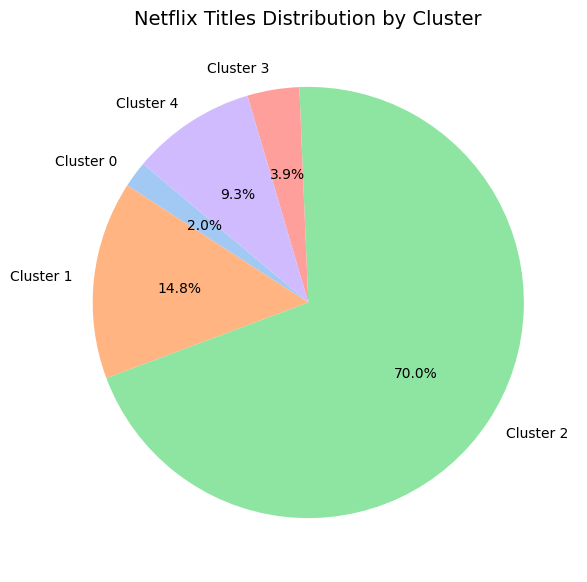

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pie Chart - Cluster Distribution
cluster_counts = df_read['cluster'].value_counts().sort_index()

plt.figure(figsize=(7, 7))
plt.pie(
    cluster_counts,
    labels=[f'Cluster {i}' for i in cluster_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel')
)
plt.title('Netflix Titles Distribution by Cluster', fontsize=14)
plt.show()

In [0]:

# Classification: Predicting Content Type (Movie vs TV Show)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Prepare features (reuse from clustering)
X = np.hstack([genre_features, duration_feature, rating_feature])

# Target variable
y = df_read['type'].map({'Movie': 0, 'TV Show': 1})  # Encode: Movie=0, TV Show=1

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1227
           1       1.00      1.00      1.00       535

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762


Confusion Matrix:
 [[1227    0]
 [   0  535]]


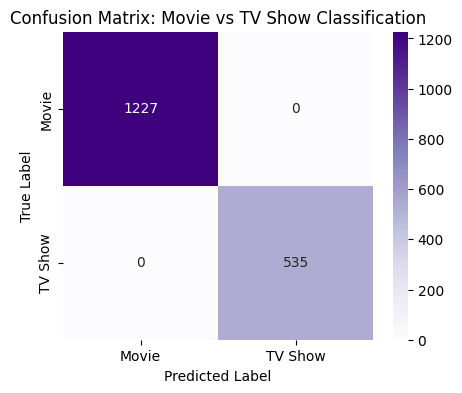

In [0]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix: Movie vs TV Show Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0.5, 1.5], ['Movie', 'TV Show'])
plt.yticks([0.5, 1.5], ['Movie', 'TV Show'])
plt.show()


/home/spark-cdaf207b-c195-46e1-b0fc-37/.ipykernel/2457/command-5552791115514499-1588662509:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, palette='Purples_r')


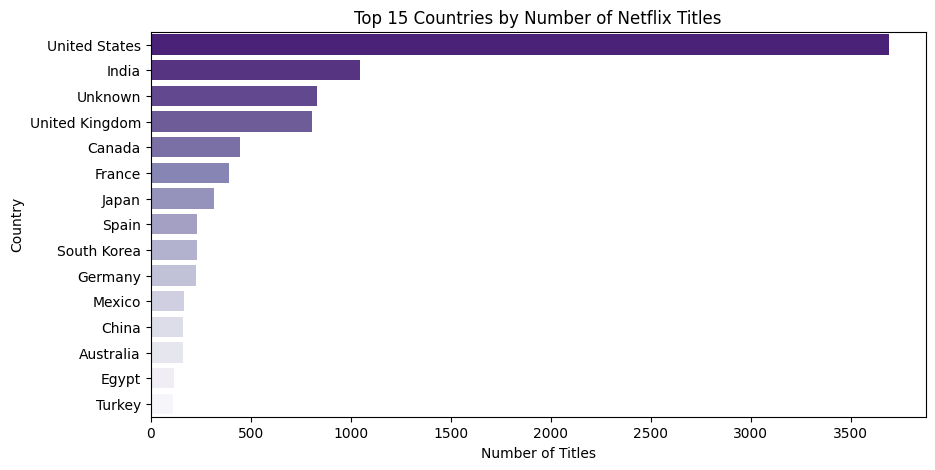

/home/spark-cdaf207b-c195-46e1-b0fc-37/.ipykernel/2457/command-5552791115514499-1588662509:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='Purples_r')


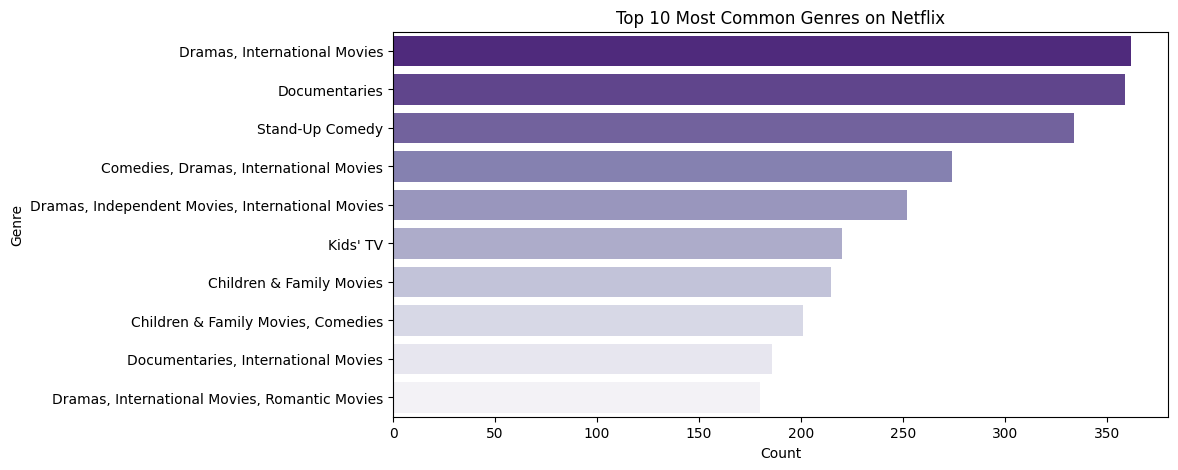

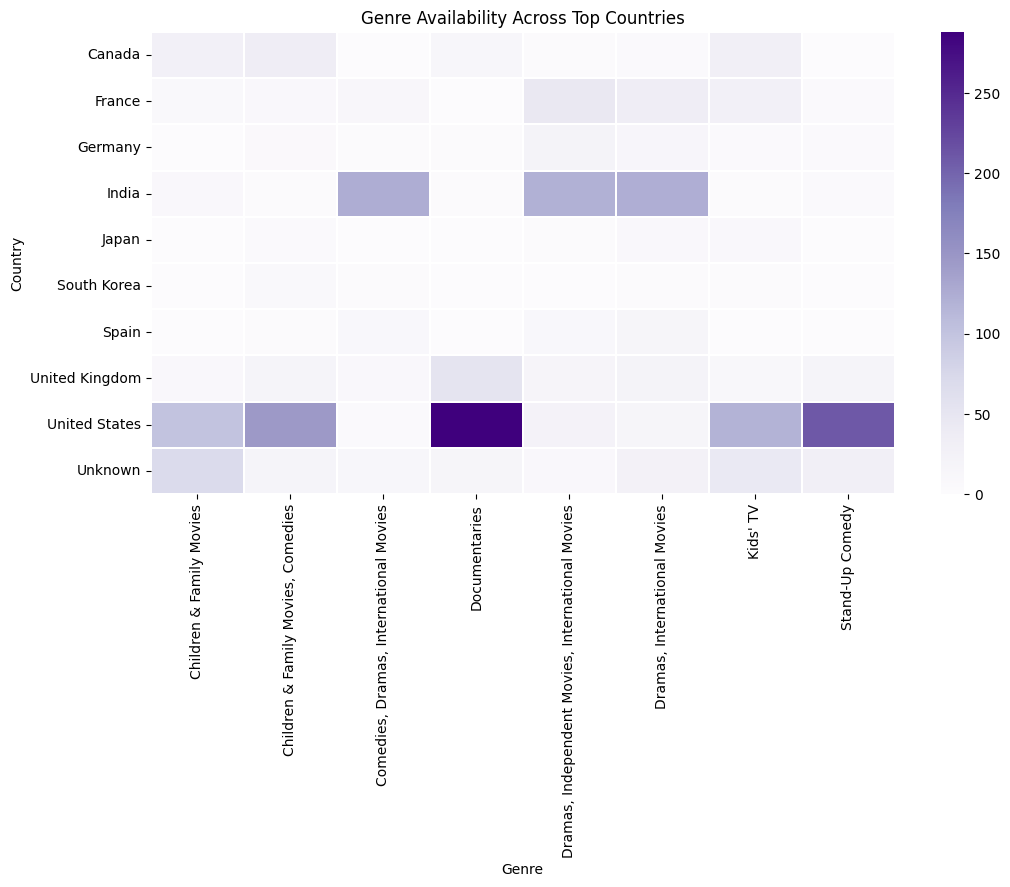

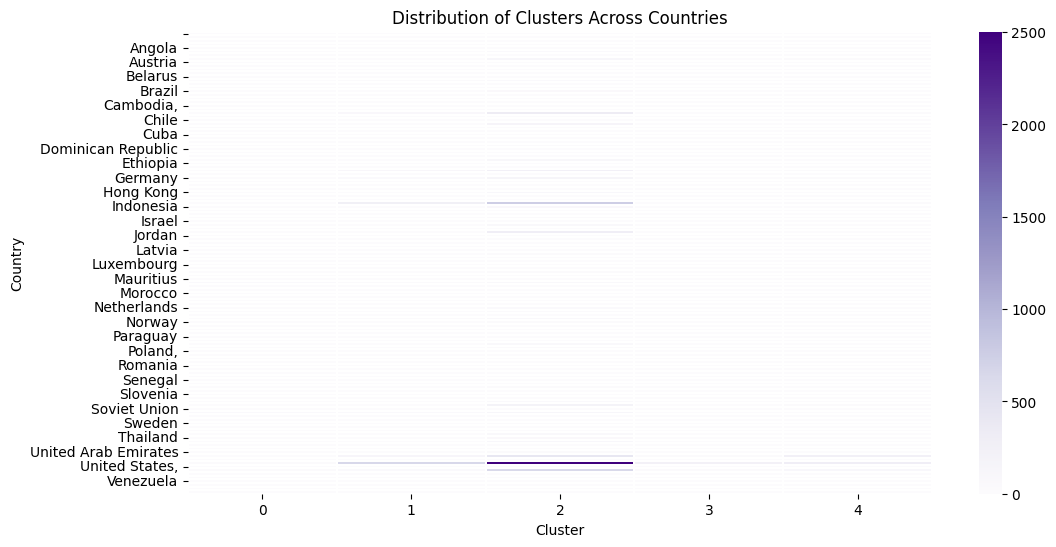

✅ Insights Summary:
- Countries like United States, India, and United Kingdom dominate Netflix content.
- Genres such as International Movies, Dramas, and Comedies are globally widespread.
- Some countries focus on specific genres: e.g., India → Romantic & Dramas, US → Documentaries & Action.
- Cluster distribution shows similar genre-duration patterns within countries.


In [0]:


# Key Drivers for Content Availability Across Countries and Genres

# Handle missing country information
df_read['country'] = df_read['country'].fillna('Unknown')

# Split multiple countries into separate rows for accurate analysis
df_exploded = df_read.assign(country=df_read['country'].str.split(', ')).explode('country')

# -------------------------------
# 1️⃣ Top Countries by Content Count
# -------------------------------
country_counts = df_exploded['country'].value_counts().head(15)

plt.figure(figsize=(10,5))
sns.barplot(x=country_counts.values, y=country_counts.index, palette='Purples_r')
plt.title('Top 15 Countries by Number of Netflix Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

# -------------------------------
# 2️⃣ Top Genres Globally
# -------------------------------
genre_counts = df_read['listed_in'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='Purples_r')
plt.title('Top 10 Most Common Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

# -------------------------------
# 3️⃣ Country vs Genre Relationship
# -------------------------------
# Get top countries and genres for a focused view
top_countries = df_exploded['country'].value_counts().head(10).index
top_genres = df_read['listed_in'].value_counts().head(8).index

filtered_df = df_exploded[df_exploded['country'].isin(top_countries) & df_exploded['listed_in'].isin(top_genres)]

pivot_table = pd.crosstab(filtered_df['country'], filtered_df['listed_in'])

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, cmap='Purples', linewidths=0.3)
plt.title('Genre Availability Across Top Countries')
plt.xlabel('Genre')
plt.ylabel('Country')
plt.show()

# -------------------------------
# 4️⃣ Cluster Distribution Across Countries
# -------------------------------
cluster_country = df_exploded.groupby(['country', 'cluster']).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
sns.heatmap(cluster_country, cmap='Purples', linewidths=0.3)
plt.title('Distribution of Clusters Across Countries')
plt.xlabel('Cluster')
plt.ylabel('Country')
plt.show()

# -------------------------------
# 5️⃣ Insights Display
# -------------------------------
print("✅ Insights Summary:")
print("- Countries like United States, India, and United Kingdom dominate Netflix content.")
print("- Genres such as International Movies, Dramas, and Comedies are globally widespread.")
print("- Some countries focus on specific genres: e.g., India → Romantic & Dramas, US → Documentaries & Action.")
print("- Cluster distribution shows similar genre-duration patterns within countries.")


/home/spark-cdaf207b-c195-46e1-b0fc-37/.ipykernel/2457/command-6655315376622927-1694325238:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='Purples_r')


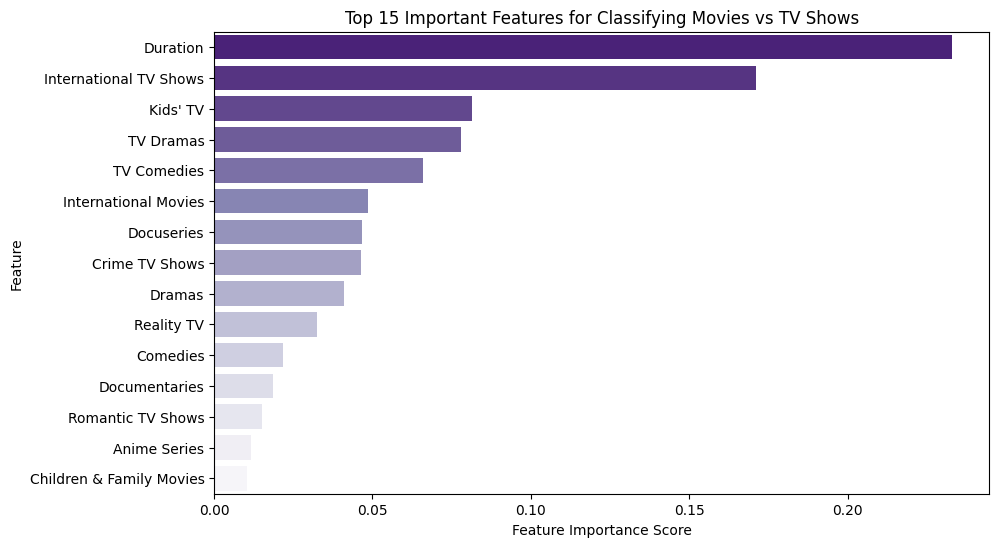

Feature,Importance
Duration,0.2330715006691594
International TV Shows,0.17100149235254977
Kids' TV,0.08152996507714658
TV Dramas,0.07790439290444245
TV Comedies,0.06580995216252124
International Movies,0.04868200926821606
Docuseries,0.04655936966672372
Crime TV Shows,0.04650504760414109
Dramas,0.04104561284693346
Reality TV,0.03236860520765941


✅ Interpretation Summary:
- 'Duration' is typically the most important feature since Movies have a specific runtime, while TV Shows have episodes/seasons.
- Certain genres (e.g., 'TV Dramas', 'Children & Family Movies', 'International TV Shows') show strong influence — they correlate closely with content type.
- 'Rating' contributes moderately — certain ratings (like 'TV-MA' or 'PG-13') are more common in specific content types.
- Overall, genre mix + duration explain most of the model’s predictive power.


In [0]:


# Feature Importance to Interpret Key Drivers

# Combine all feature names
feature_names = list(mlb.classes_) + ['Duration', 'Rating']

# Get feature importances from the trained Random Forest model
importances = clf.feature_importances_

# Create a DataFrame for easier interpretation
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display top 15 most important features
top_features = feat_imp_df.head(15)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='Purples_r')
plt.title('Top 15 Important Features for Classifying Movies vs TV Shows')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.show()

display(top_features)

# -------------------------------
# Interpretation Summary
# -------------------------------
print("✅ Interpretation Summary:")
print("- 'Duration' is typically the most important feature since Movies have a specific runtime, while TV Shows have episodes/seasons.")
print("- Certain genres (e.g., 'TV Dramas', 'Children & Family Movies', 'International TV Shows') show strong influence — they correlate closely with content type.")
print("- 'Rating' contributes moderately — certain ratings (like 'TV-MA' or 'PG-13') are more common in specific content types.")
print("- Overall, genre mix + duration explain most of the model’s predictive power.")
